In [20]:
pip install -U langchain langgraph langsmith langchain-openai python-dotenv requests beautifulsoup4 pydantic ipykernel


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install langchain-ollama

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

print("Environment loaded")
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))

Environment loaded
LangSmith tracing: true


In [ ]:
import ollama

Response = ollama.chat(
    model="qwen2.5:3b",
    messages=[{"role": "user", "content": "Explain RAG in one sentence."}],
    options={"temperature": 0}
)
print(Response['message']['content'])

RAG stands for Retrieval-Augmented Generation, which is a method that uses retrieval techniques to enhance the quality of text generation models by incorporating relevant documents into the model's input or training data.


In [24]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="qwen2.5:3b", temperature=0)  # llm is the MODEL object
response = llm.invoke("What is the difference between RAG and fine-tuning?")
print(response.content)

RAG (Retrieval-Augmented Generation) and fine-tuning are both techniques used in natural language processing, but they serve different purposes and operate at different levels of the model's training process.

### Fine-Tuning:
Fine-tuning refers to a technique where you take a pre-trained model that has been trained on a large dataset (often a general-purpose dataset like Wikipedia or CommonCrawl) and then adjust its parameters specifically for a new task. This is done by using your specific data, which can be much smaller in scale but more relevant to the task at hand. The goal of fine-tuning is to improve the model's performance on this specific task.

For example, if you have a pre-trained language model that was trained on general text and you want it to perform better on tasks like sentiment analysis or question answering, you would fine-tune the model using your dataset of interest. This involves retraining the model for a few epochs (typically 1-5) with your specific data.

### 

In [45]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from serpapi import GoogleSearch
from langchain_core.tools import tool

In [35]:
class ResearchState(TypedDict):
    query: str
    result: str

In [36]:
def researcher(state: ResearchState):
    query = state["query"]

    response = llm.invoke(
        f"""
        Research the following topic conceptually:

        {query}

        Give me the most important information.
        """
    )

    return {
        "result": response.content
    }

In [37]:
builder = StateGraph(ResearchState)

builder.add_node("researcher", researcher)

builder.add_edge(START, "researcher")
builder.add_edge("researcher", END)

graph = builder.compile()

In [38]:
result = graph.invoke({
    "query": "What is Retrieval-Augmented Generation?",
    "result": ""
})

print(result)

{'query': 'What is Retrieval-Augmented Generation?', 'result': 'Retrieval-Augmented Generation (RAG) is an advanced approach in natural language processing that combines two key components: retrieval and generation. The primary goal of RAG is to enhance the effectiveness of large pre-trained models by integrating them with a database or knowledge base, allowing these models to access additional information beyond their training data.\n\n### Key Components:\n\n1. **Retrieval**: This component involves using search engines, databases, or other sources to find relevant documents or pieces of information that can be used as context for the generation process.\n2. **Generation**: This refers to the use of a large language model (such as GPT-3) to generate text based on the retrieved data.\n\n### How RAG Works:\n\n1. **Query Processing**: The user provides a query, which is then sent to the retrieval component to find relevant documents or information.\n2. **Retrieval Component**: This part 

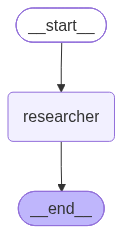

In [39]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

python Function

In [43]:
def google_search(query: str):
    search = GoogleSearch({
        "q": query,
        "api_key": SERPAPI_API_KEY,
        "engine": "google",
        "num": 5
    })

    results = search.get_dict()

    return results.get("organic_results", [])

In [44]:
results = google_search("latest developments in RAG")

for result in results:
    print(result.get("title"))
    print(result.get("link"))
    print()

What is RAG? Latest Advances in Retrieval-Augmented ...
https://squirro.com/squirro-blog/state-of-rag-genai

Advancements in RAG: A Comprehensive Survey of ...
https://medium.com/@sahin.samia/advancements-in-rag-a-comprehensive-survey-of-techniques-and-applications-b6160b035199

NirDiamant/RAG_Techniques: This repository showcases ...
https://github.com/NirDiamant/rag_techniques

8 Latest RAG Advancements Every Developer Should Know
https://zilliz.com/blog/8-latest-rag-advancements-every-developer-should-know

Retrieval Augmented Generation (RAG) for LLMs
https://www.promptingguide.ai/research/rag

RAG Techniques
https://www.ibm.com/think/topics/rag-techniques

Advanced RAG techniques for high-performance LLM ...
https://neo4j.com/blog/genai/advanced-rag-techniques/

[2410.12837] A Comprehensive Survey of Retrieval- ...
https://arxiv.org/abs/2410.12837

What is RAG (Retrieval-Augmented Generation)?
https://aws.amazon.com/what-is/retrieval-augmented-generation/



langchain tool

In [46]:
@tool
def google_search_tool(query: str) -> list:
    """
    Search Google and return the top results.
    """

    search = GoogleSearch({
        "q": query,
        "api_key": SERPAPI_API_KEY,
        "engine": "google",
        "num": 5
    })

    results = search.get_dict()

    return results.get("organic_results", [])

In [47]:
print(google_search_tool.name)
print(google_search_tool.description)

google_search_tool
Search Google and return the top results.


LangChain allows a model to know about tools.

In [48]:
llm_with_tools = llm.bind_tools(
    [google_search_tool]
)

In [49]:
response = llm_with_tools.invoke(
    "Find information about the latest developments in RAG."
)

In [50]:
print(response)

content='' additional_kwargs={} response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-08-23T14:01:11.2729332Z', 'done': True, 'done_reason': 'stop', 'total_duration': 53554506300, 'load_duration': 48173837900, 'prompt_eval_count': 157, 'prompt_eval_duration': 2752054000, 'eval_count': 31, 'eval_duration': 2435372000, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'} id='lc_run--01a02eec-0f7c-7201-bc42-89bed54171b1-0' tool_calls=[{'name': 'google_search_tool', 'args': {'query': 'latest developments RAG'}, 'id': '0f813e79-8679-4702-94b3-939d0a0514ee', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 157, 'output_tokens': 31, 'total_tokens': 188}


In [51]:
from typing import TypedDict, List, Dict, Any

class ResearchState(TypedDict):
    query: str
    search_results: List[Dict[str, Any]]
    extracted_content: List[str]
    analysis: str
    summary: str

In [60]:
def research_node(state: ResearchState):

    query = state["query"]

    response = llm.invoke(
        f"""
        You are a research assistant.

        Convert the following user question into a concise
        Google search query.

        User question:
        {query}

        Return ONLY the search query.
        """
    )

    search_query = response.content.strip()

    results = google_search(search_query)

    return {
        "search_results": results
    }

In [53]:
import requests
from bs4 import BeautifulSoup

In [54]:
def extract_text(url: str) -> str:

    try:
        response = requests.get(
            url,
            timeout=10,
            headers={
                "User-Agent": "Mozilla/5.0"
            }
        )

        response.raise_for_status()

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        for element in soup(
            ["script", "style", "nav", "footer"]
        ):
            element.decompose()

        text = soup.get_text(
            separator=" ",
            strip=True
        )

        return text

    except Exception as e:
        return f"Extraction failed: {e}"

In [55]:
url = results[0]["link"]

text = extract_text(url)

print(text[:2000])

What is RAG? Latest Advances in Retrieval-Augmented Generation Skip to article Skip to main content Land small, prove fast, expand - Explore the Squirro AI Agent Catalog – Download Now Open main navigation Close main navigation Book a Demo search Search Blog State of RAG in 2026: GraphRAG, Guardrails & Enterprise ROI By Jan Overney January 19, 2026 · 18 min read Share Link copied Retrieval Augmented Generation (RAG) Comes of Age: Addressing Enterprise AI Challenges In the race for AI-driven transformation, many enterprises find themselves grappling with a critical paradox: how to unleash the power of LLMs without compromising data accuracy, regulatory compliance, or spiraling operational costs. Outdated insights, hallucinated outputs, and the prohibitive expense of continuous model retraining are no longer just technical hurdles – they're quickly morphing into direct threats to ROI and competitive advantage. In 2026, retrieval augmented generation (RAG) is not just a solution; it's the

In [56]:
def extraction_node(state: ResearchState):

    results = state["search_results"]

    extracted = []

    for result in results[:5]:

        url = result.get("link")

        if not url:
            continue

        text = extract_text(url)

        if text:
            extracted.append(text)

    return {
        "extracted_content": extracted
    }

In [57]:
def analysis_node(state: ResearchState):

    query = state["query"]
    documents = state["extracted_content"]

    context = "\n\n--- SOURCE ---\n\n".join(
        documents
    )

    response = llm.invoke(
        f"""
        You are a research analyst.

        User question:
        {query}

        Below are documents collected from the web:

        {context}

        Analyze the information.

        Identify:
        - the most important facts
        - major themes
        - important differences
        - useful conclusions
        - conflicting information

        Do not invent information.
        Base your analysis only on the provided content.
        """
    )

    return {
        "analysis": response.content
    }

In [58]:
def summary_node(state: ResearchState):

    query = state["query"]
    analysis = state["analysis"]

    response = llm.invoke(
        f"""
        You are a concise research writer.

        User question:
        {query}

        Research analysis:
        {analysis}

        Produce a concise and useful answer.

        Requirements:
        - directly answer the question
        - include the most important findings
        - avoid unnecessary detail
        - use bullet points when useful
        - do not invent information
        """
    )

    return {
        "summary": response.content
    }

In [61]:
builder = StateGraph(ResearchState)

builder.add_node("research", research_node)
builder.add_node("extract", extraction_node)
builder.add_node("analyze", analysis_node)
builder.add_node("summarize", summary_node)

builder.add_edge(START, "research")
builder.add_edge("research", "extract")
builder.add_edge("extract", "analyze")
builder.add_edge("analyze", "summarize")
builder.add_edge("summarize", END)

graph = builder.compile()

In [62]:
result = graph.invoke({
    "query": "What are the latest developments in RAG systems?",
    "search_results": [],
    "extracted_content": [],
    "analysis": "",
    "summary": ""
})

In [63]:
print(result["summary"])

### Latest Developments in RAG Systems

- **Integrating Large Language Models with Knowledge Bases**: RAG systems extend LLM capabilities by linking them to authoritative knowledge bases, enhancing accuracy and relevance of responses.

- **Cost-Effectiveness**: Compared to retraining LLMs for specific domains or organizations, RAG is a more cost-effective approach.

- **Current Information**: By connecting LLMs directly to live data sources like social media feeds and news sites, RAG enables the provision of up-to-date information.

- **User Trust**: Providing accurate responses with source attribution enhances user trust in generative AI solutions.

- **Developer Control**: Developers can control the information sources used by LLMs, ensuring appropriate responses are generated.

### Additional Insights:

- **AWS Integration**: Solutions like Amazon Bedrock and Amazon Kendra provide scalable RAG implementations on AWS platforms, simplifying development and maintenance while maintainin

In [64]:
print("SEARCH RESULTS:")
print(len(result["search_results"]))

print("\nEXTRACTED DOCUMENTS:")
print(len(result["extracted_content"]))

print("\nANALYSIS:")
print(result["analysis"])

print("\nFINAL SUMMARY:")
print(result["summary"])

SEARCH RESULTS:
9

EXTRACTED DOCUMENTS:
5

ANALYSIS:
### Most Important Facts:

- **Retrieval-Augmented Generation (RAG)**: It is a process that extends the capabilities of large language models by integrating them with authoritative knowledge bases, allowing for more accurate and relevant responses to user queries.

- **Benefits**:
  - Cost-effective implementation.
  - Ability to provide current information.
  - Enhanced user trust through source attribution.
  - More developer control over LLM's information sources.

### Major Themes:

1. **Integrating Large Language Models with Knowledge Bases**: RAG allows large language models (LLMs) to reference external knowledge bases, improving their accuracy and relevance in various contexts.
2. **Cost-Effectiveness**: Compared to retraining the LLM for specific domains or organizations, RAG is a more cost-effective approach.
3. **Current Information**: RAG enables developers to provide up-to-date information by connecting LLMs directly to l